# **Business Understanding**

A simple yet challenging project, to predict the housing price based on certain factors like house area, bedrooms, furnished, nearness to mainroad, etc. The dataset is small yet, it's complexity arises due to the fact that it has strong multicollinearity. Can you overcome these obstacles & build a decent predictive model?


*Objective:*
Run a predition using a linear regression model.

*Acknowledgement:*
Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.

Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.



*Source*: [Housing Data](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

#### **Loading Libraries**

In [64]:
import pandas as pd # data manipulation and reading the dat as a dataframe
import seaborn as sns # visualizations
from sklearn.linear_model import LinearRegression # we use sklearn as it composes many ML algorithms that we can use
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score # evaluation metric  - R^2
from sklearn.preprocessing import OneHotEncoder # encoding 

#### **Loading data**

In [65]:
df = pd.read_csv("data/Housing.csv")

# **Data Understanding**

##### **Snippet of the data**

In [66]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


##### **Shape of data**

In [67]:
rows, columns = df.shape
output = f" Housing data is composed of {rows} records and {columns} features"
print(output)

 Housing data is composed of 545 records and 13 features


##### **Get general info**

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


##### **statistical summary**

In [69]:
df.describe() # this captures the numerical columns

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [70]:
df.describe(include="object") # this captures the non-numerical columns

/tmp/ipykernel_4897/243942468.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object") # this captures the non-numerical columns


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


##### **Univariate analysis**

In [71]:
df['area'].describe() # this captures the numerical columns

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

##### **Bi-variate analysis**

In [72]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

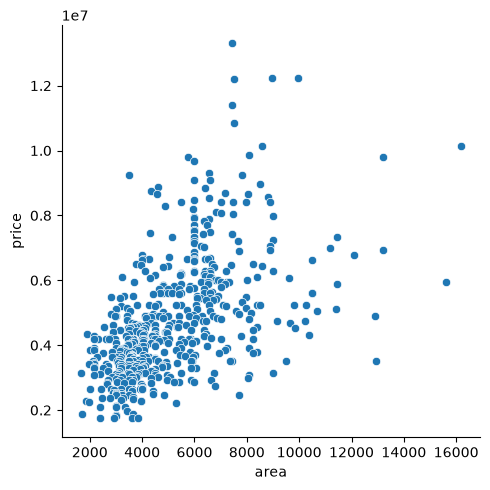

In [73]:
sns.relplot(data=df, x="area", y="price")

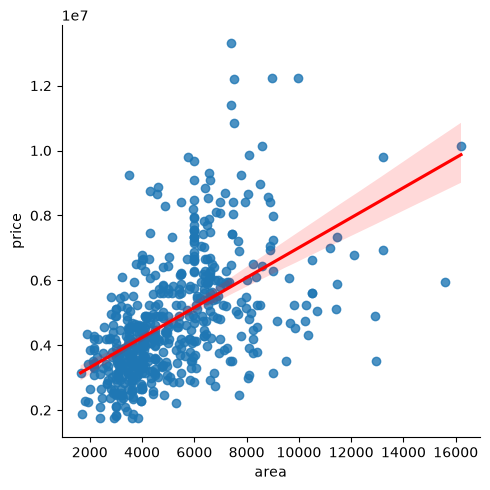

In [74]:
sns.lmplot(data=df, x="area", y="price",line_kws= {"color" : "red"})

#### **Multi-variate Analysis**

In [75]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [76]:
df['furnishingstatus'].unique()

<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

Encoding using pandas.get_dummies

In [77]:
one_hot = pd.get_dummies(df['furnishingstatus'], dtype=int)
one_hot

,furnished,semi-furnished,unfurnished
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
540,0,0,1
541,0,1,0
542,0,0,1
543,1,0,0


Encoding using Onehot encoder

In [78]:
encoder = OneHotEncoder(handle_unknown='ignore') # instance
encoder.fit(df[['furnishingstatus']]) # fit to get the classes 
encoder.categories_ # lists our categories

[array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)]

In [79]:
encoded_furnishing_status= encoder.transform(df[['furnishingstatus']]).toarray()

#  the essence of this DF is basically to represent the valiues in independent features
encoded_df = pd.DataFrame(
    encoded_furnishing_status, 
    columns= encoder.get_feature_names_out(['furnishingstatus'])
)
# enc.get_feature_na_mes_out(['gender', 'group'])

In [80]:
encoded_df.head(20)

,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
5,0.0,1.0,0.0
6,0.0,1.0,0.0
7,0.0,0.0,1.0
8,1.0,0.0,0.0
9,0.0,0.0,1.0


Encoding the binary columns

In [81]:
binary_columns = ['mainroad','guestroom','basement',	'hotwaterheating','airconditioning','prefarea']

for col in binary_columns:
    df[col] = df[col].map({'yes':1, 'no':0})

In [82]:
df.columns # command to list out columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [83]:
target_columns = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea'] # dropped 'furnishingstatus' temporarily
df_3 = df[target_columns]
df_3.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,1,0,0,0,1,2,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0


In [101]:
df_4 = pd.concat([df_3,encoded_df ])

In [102]:
df_4

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000.0,7420.0,4.0,2.0,3.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,NaN,NaN,NaN
1,12250000.0,8960.0,4.0,4.0,4.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,NaN,NaN,NaN
2,12250000.0,9960.0,3.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,NaN,NaN,NaN
3,12215000.0,7500.0,4.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,3.0,1.0,NaN,NaN,NaN
4,11410000.0,7420.0,4.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,2.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0
541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0
542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0
543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0


yes = 1, no = 0 # in abinary situation itis ok

red = 0   green = 1  blue = 2 3 if we encode in this manner the algorithm will assume there exists some inherent order

Encoding of Data

<Axes: >

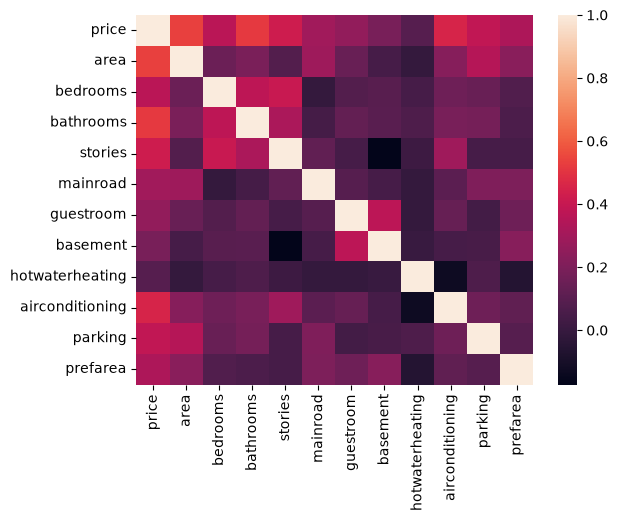

In [84]:
sns.heatmap(df_3.corr())

<Axes: >

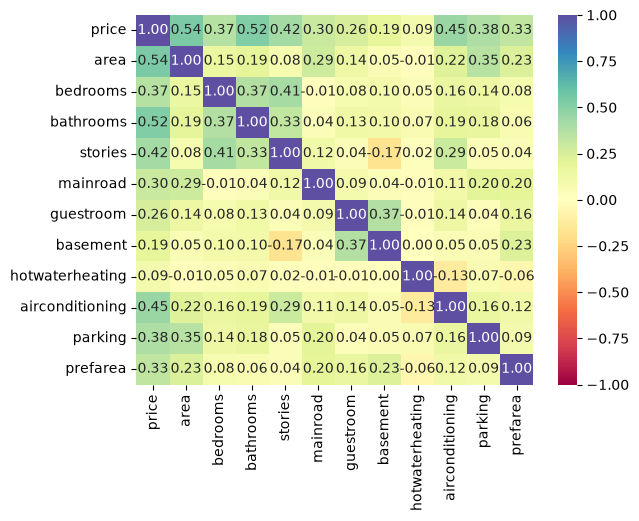

In [85]:
sns.heatmap(df_3.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

Findings:
- The data set is most likely non-linear in nature( implying that there is a possibility of the featurs not being directy related)


# **Data Preparation**

Note: 
- We are dealing with a simple linear regression problem , our target variable is *"price"* and our independent variable is *"area"*

In [86]:
df_2 = df [["price","area"]] # picking the features we need since we are focusing on a simple linear regression
df_2.head()

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


# **Modeling**

In [87]:
df_2.shape

(545, 2)

Converting the extracted columns to a data frame

In [88]:
X = pd.DataFrame(df_2["area"]) # independent variable
y = pd.DataFrame(df_2["price"]) # target/ dependent variable

Splitting our data for modeling. 
- Training data(train & test), is data that we let the model learn about or rather we expose it to the model
- Testing Data, is data that we expose to the model to allow it to generate and answer and based on those answers we compare them with the test answers

Our data size is small hence splitting to the ration of 80% of training 20% of testing is not ideal here, what we can do is split it to 70 of training and 30% of testing


In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=30, random_state= 42)
#random_state => is a mathematical formular that retains the sequence of number selection in a set of numbers ( enables reproducability of the selection)

In [90]:
linear_reg_model = LinearRegression() # creates an instance of the model
linear_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Training the Model: Letting the model learn from our data 

In [91]:
linear_reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[438.46]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2516004.13]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Scenario whereby we are basically predicting th eproce of a house based on user_inputed area

In [92]:
user_input_area = int(input("What is the area of the place you would like to stay? (type numbers only): "))
y_hat = linear_reg_model.predict([[user_input_area]])

/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [93]:
y_hat[0][0]

np.float64(7928405.329418704)

In [94]:
X_test

,area
316,5900
77,6500
360,4040
90,5000
493,3960
209,6720
176,8520
249,4990
516,3240
426,2700


In [95]:
linear_reg_model.predict([[4950]])

/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/ML-Series/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[4686401.56307668]])

In [96]:
y_predicted = linear_reg_model.predict(X_test)

In [97]:
y_test

,price
316,4060000
77,6650000
360,3710000
90,6440000
493,2800000
209,4900000
176,5250000
249,4543000
516,2450000
426,3353000


In [98]:
y_predicted

array([[5102942.48517905],
       [5366020.96229634],
       [4287399.20611546],
       [4708324.76950312],
       [4252322.07583316],
       [5462483.07057267],
       [6251718.50192453],
       [4703940.12821783],
       [3936627.90329241],
       [3699857.27388685],
       [6278026.34963626],
       [4240922.00849141],
       [4147090.68498624],
       [3875242.92529838],
       [4256706.71711844],
       [4107628.91341865],
       [3392932.38391669],
       [5146788.89803193],
       [5081019.27875261],
       [5146788.89803193],
       [4717094.05207369],
       [5508521.8040682 ],
       [4115959.7318607 ],
       [4182167.81526855],
       [6133333.18722175],
       [6883106.84700602],
       [3870858.28401309],
       [3831396.5124455 ],
       [8303730.62343937],
       [3831396.5124455 ]])

ECVALUATION - 1
Digest - 0

# **Evaluation**

focusing on using R squared: 
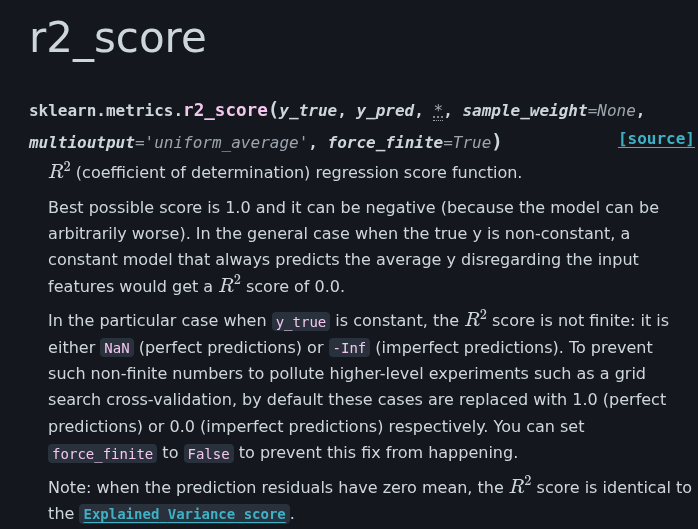

In [99]:
r2_score(y_test, y_predicted)

0.46590120608285235

findings:

- interpretation: The model only captures 26.8667% of the data. Hence, our model is poorly performing, reason being, the outcome tends towards 0(bad performance) as opposed to 1(good performance)

# **Deployment**